#2408235
#Diksha Maharjan

**Task 1 Prepare Dataset**

In [ ]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical # For one-hot encoding

# Define your base paths
train_dir = '/content/drive/MyDrive/Artificial-Intelligence-And-Machine-Learning-Materials/Week 4/devnagari digit/DevanagariHandwrittenDigitDataset/Train'
test_dir = '/content/drive/MyDrive/Artificial-Intelligence-And-Machine-Learning-Materials/Week 4/devnagari digit/DevanagariHandwrittenDigitDataset/Test'

In [ ]:
def process_dataset(base_path, img_size=(28, 28)):
  images = []
  labels = []

  # Get sorted list of folders (digit_0, digit_1... digit_9)
  # Sorting ensures digit_0 maps to label 0, digit_1 to 1, etc.
  digit_folders = sorted([f for f in os.listdir(base_path) if f.startswith('digit_')])
  for folder in digit_folders:
    label =  int(folder.split('_')[-1])
    folder_path = os.path.join(base_path, folder)
    for img_name in os.listdir(folder_path):
      img_path = os.path.join(folder_path, img_name)
      try:
        #Load with PIL
        with Image.open(img_path) as img:
          #Resize to consistent shape
          img = img.resize(img_size)
          #covert to grayscale and numpy array
          img_array = np.array(img.convert('L'))

          images.append(img_array)
          labels.append(label)
      except Exception as e:
        print(f"Error processing image {img_path}: {e}")
  # convert lists to numpy arrays
  X = np.array(images)
  y = np.array(labels)
  # Normalize to range 0-1
  # since pixel values are 0 - 255, we divide by 255.0
  X = X.astype('float32') / 255.0
  #One hot encoding for labels
  y_encoded = to_categorical(y, num_classes=10)
  return X, y_encoded


In [ ]:
# Process Training Data
print("Processing training Data")
X_train, y_train = process_dataset(train_dir)

Processing training Data


In [ ]:
print("Processing testing Data")
X_test, y_test = process_dataset(test_dir)

Processing testing Data


In [ ]:
#Verify results
print(f"\n Training set: {X_train.shape}, labels: {y_train.shape}")
print(f"Testing set: {X_test.shape}, Labels: {y_test.shape}")


 Training set: (17000, 28, 28), labels: (17000, 10)
Testing set: (3000, 28, 28), Labels: (3000, 10)


**Task 2 Build the FCN model**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Initialize the sequential model
model = Sequential()

# Add the flatten layer to convert 2D images to 1D vectors
# this is necessary because Dense layers dont see 2D shapes
model.add(Flatten(input_shape=(28, 28)))

# Add the hidden layers
# 1st hidden layer: 64 neurons, sigmoid activation
model.add(Dense(64, activation='sigmoid'))

# 2nd hidden layer: 128 neurons, sigmoid activation
model.add(Dense(128, activation='sigmoid'))

# 3rd hidden layer: 256 neurons, sigmoid activation
model.add(Dense(256, activation='sigmoid'))

# Add the output layer
# 10 units  for 10 digits, softmax for probabiltity distribution
model.add(Dense(10, activation='softmax'))

#view the architecture summary
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

**Task 3 Compile the model**

Model Compilation
• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [ ]:
# Compiling the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


**Task 4 train the model**

In [ ]:
from sys import path_importer_cache
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Define Callbacks
# Stop training id validation loss does not improve for 3 straights epochs
early_stopping =  EarlyStopping(
    monitor =  'val_loss',
    patience = 3,
    restore_best_weights = True
)

#Save only the best version of the model based on validation accuracy
checkpoint = ModelCheckpoint(
    'best_devnagari_model.keras',
    monitor = 'val_accuracy',
    save_best_only = True
)

# Shuffle the training data
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)

X_train = X_train[indices]
y_train = y_train[indices]

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs = 20,
    batch_size = 128,
    validation_split = 0.2,
    callbacks = [early_stopping, checkpoint]
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6940 - loss: 0.9738 - val_accuracy: 0.8032 - val_loss: 0.5820
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8429 - loss: 0.4544 - val_accuracy: 0.8782 - val_loss: 0.3697
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9079 - loss: 0.3031 - val_accuracy: 0.9215 - val_loss: 0.2656
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9424 - loss: 0.2111 - val_accuracy: 0.9391 - val_loss: 0.1985
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9561 - loss: 0.1597 - val_accuracy: 0.9479 - val_loss: 0.1715
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9649 - loss: 0.1282 - val_accuracy: 0.9521 - val_loss: 0.1539
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9729 - loss: 0.1041 - val_accuracy: 0.9597 - val_loss: 0.1315
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9774 - loss: 0.0867 - val_accuracy

**Task 5 Evaluate the Model**

In [ ]:
# Evaluate on the unseen test set

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"\n ---- Final Results ----")
print(f"Test Loss: {test_loss: 4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9767 - loss: 0.0908

 ---- Final Results ----
Test Loss:  0.090805
Test Accuracy: 97.67%


Performance Visualization

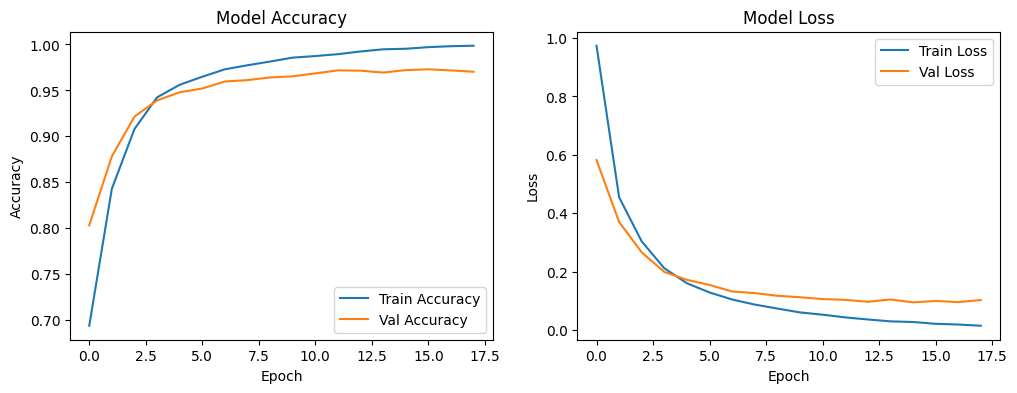

In [ ]:
import matplotlib.pyplot as plt

# Plot Training vs Validation Accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Training vs Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Detailed Analysis

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


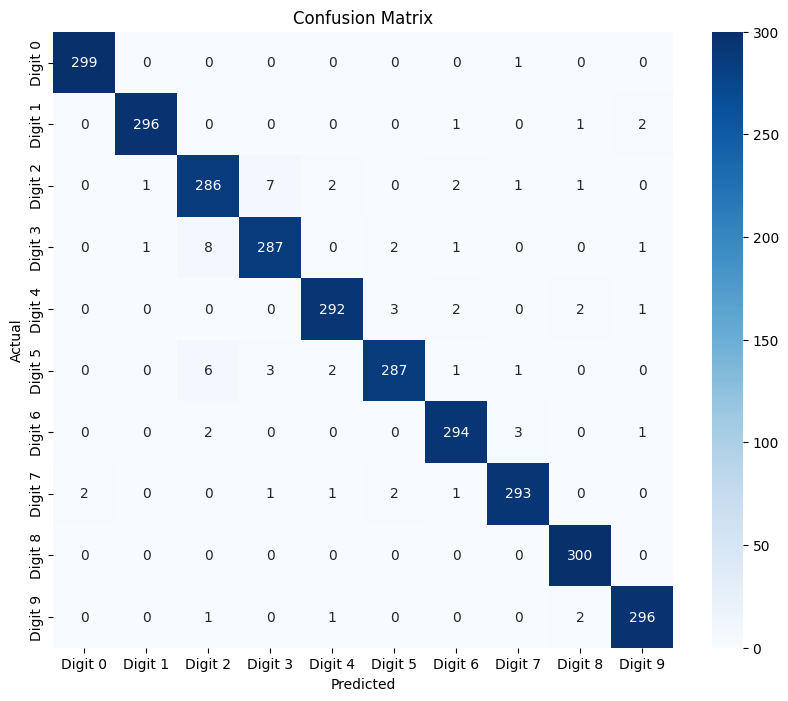

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       300
           1       0.99      0.99      0.99       300
           2       0.94      0.95      0.95       300
           3       0.96      0.96      0.96       300
           4       0.98      0.97      0.98       300
           5       0.98      0.96      0.97       300
           6       0.97      0.98      0.98       300
           7       0.98      0.98      0.98       300
           8       0.98      1.00      0.99       300
           9       0.98      0.99      0.99       300

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Digit {i}' for i in range(10)],
            yticklabels=[f'Digit {i}' for i in range(10)])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print detailed precision/recall
print(classification_report(y_true, y_pred_classes))

**Task 6: Save and Load the Model**

In [ ]:
# save the model to an .h5 file
model.save('Devnagari_digit_model.h5')
print("Model save as devnagari_digit_model.h5")



Model save as devnagari_digit_model.h5


In [ ]:
# Load the saved model

from tensorflow.keras.models import load_model
loaded_model = load_model('Devnagari_digit_model.h5')
print("Succesfully loaded")

Succesfully loaded


In [ ]:
# Re-evaluate to ensure performance is identical
loss, acc = loaded_model.evaluate(X_test, y_test, verbose=0)
print(f"Re-evaluated Test Accuracy: {acc*100:.2f}%")

Re-evaluated Test Accuracy: 97.67%


**Task 7 Making prediction**

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


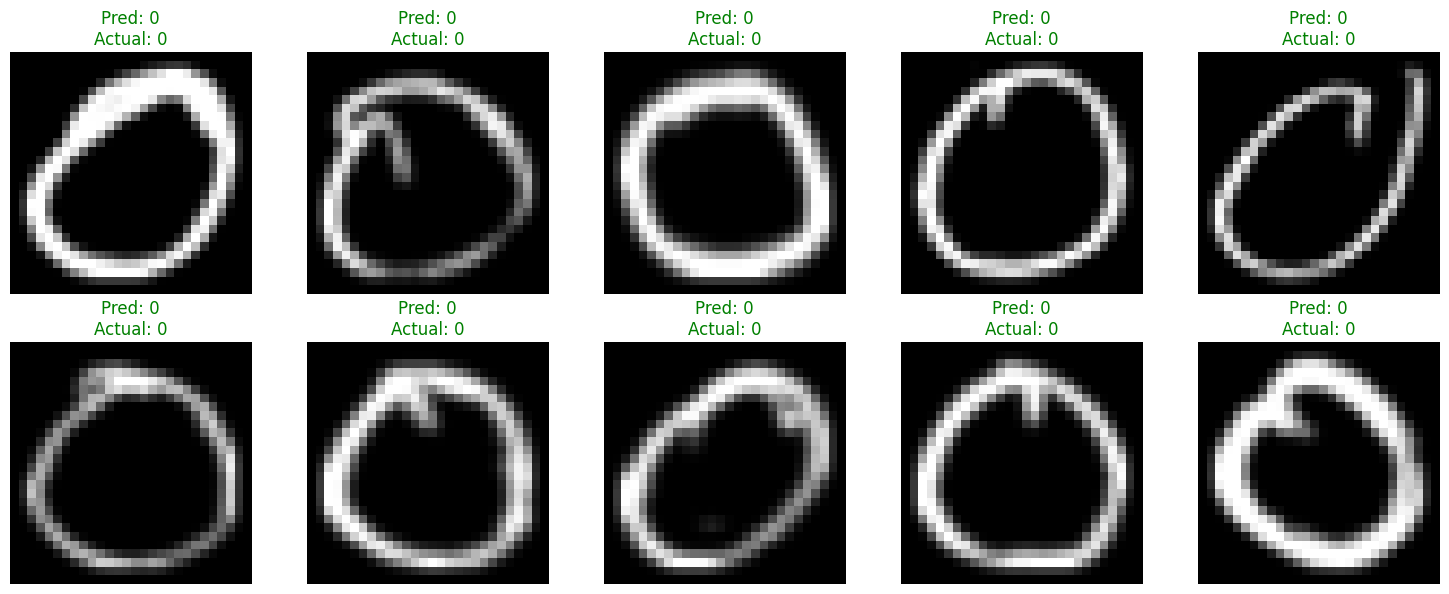

In [ ]:
import matplotlib.pyplot as plt

# Use the model to predict on the entire test set ( or a slice)
predictions = loaded_model.predict(X_test)

# Convert probabilities to digit labels using np.argmax()
predicted_labels = np.argmax(predictions, axis=1)
actual_labels = np.argmax(y_test, axis=1)

# Visualize the first 10 predictions
plt.figure(figsize=(15, 6))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(X_test[i], cmap='gray')

# Get the single integer for the actual class
  true_digit = np.argmax(y_test[i])
  pred_digit = predicted_labels[i]

  color = 'green' if predicted_labels[i] == actual_labels[i] else 'red'
  plt.title(f"Pred: {pred_digit}\nActual: {true_digit}", color=color)
  plt.axis('off')

plt.tight_layout()
plt.show()
